In [12]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json

# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [13]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_ee_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']

## Plot Efficiencies

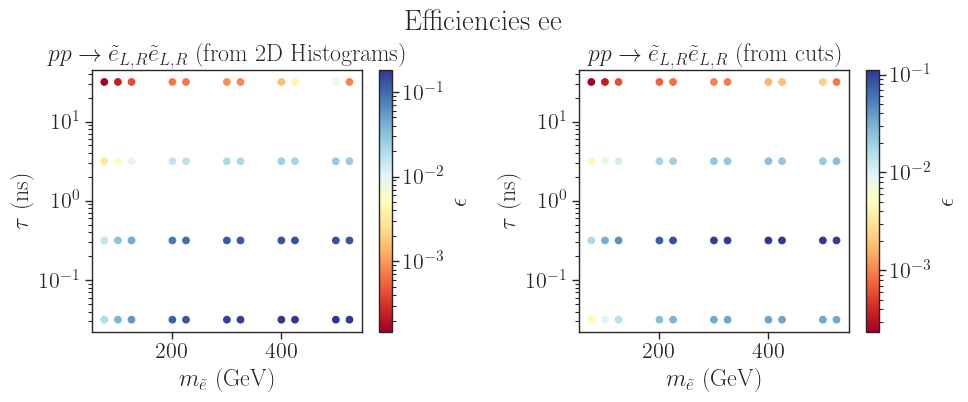

In [14]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

title = r'$p p \to \tilde{e}_{L,R} \tilde{e}_{L,R}$'
for iax,ax in enumerate(axList):
    df = dfRecast
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    if iax == 0:
        z = df['AccEff_ee']
        tit_append = ' (from 2D Histograms)'
    elif iax == 1:
        z = df['AccEffCuts_ee']
        tit_append = ' (from cuts)'
    else:
        raise ValueError("Invalid subplot index")

    im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(title + tit_append)

plt.tight_layout()
plt.suptitle('Efficiencies ee', y=1.02)
plt.show()

## Plot Efficiency Uncertainties

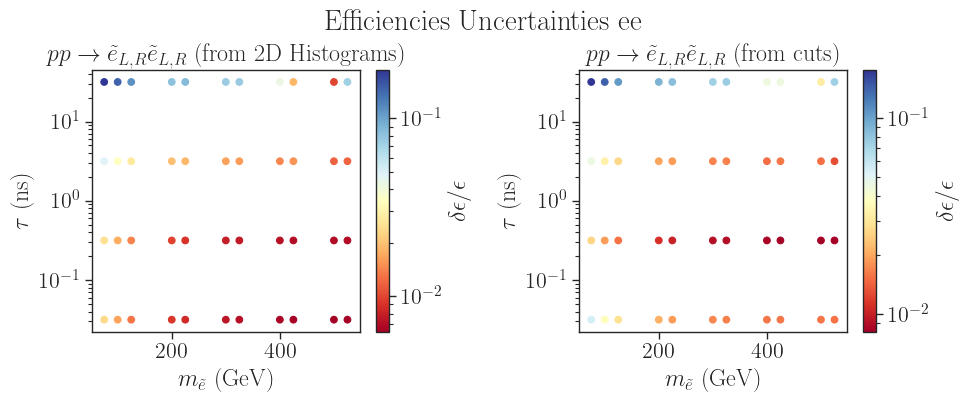

In [15]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

title = r'$p p \to \tilde{e}_{L,R} \tilde{e}_{L,R}$'
for iax,ax in enumerate(axList):
    df = dfRecast
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    if iax == 0:
        z = df['AccEff_ee_err']/df['AccEff_ee']
        tit_append = ' (from 2D Histograms)'
    elif iax == 1:
        z = df['AccEffCuts_ee_err']/df['AccEffCuts_ee']
        tit_append = ' (from cuts)'
    else:
        raise ValueError("Invalid subplot index")

    im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\delta \epsilon / \epsilon$')

    ax.set_title(title + tit_append)

plt.tight_layout()
plt.suptitle('Efficiencies Uncertainties ee', y=1.02)
plt.show()

## Compare with ATLAS results

In [21]:
atlasEff =  pd.read_csv('../ATLAS_data/HEPData-ins1831504-v2-csv/Selectronefficiency.csv',comment='#')
atlasEff['tau0_ns'] = (10**atlasEff["Lifetime [log10(ns)]"]).apply(lambda x: float(f'{x:.2e}'))
atlasEff.drop(columns=['Lifetime [log10(ns)]'], inplace=True)
atlasAcc =  pd.read_csv('../ATLAS_data/HEPData-ins1831504-v2-csv/Selectronacceptance.csv',comment='#')
atlasAcc['tau0_ns'] = (10**atlasAcc["Lifetime [log10(ns)]"]).apply(lambda x: float(f'{x:.2e}'))
atlasAcc.drop(columns=['Lifetime [log10(ns)]'], inplace=True)
atlas_ee = atlasEff.merge(atlasAcc, on=['tau0_ns','Mass [GeV]'], how='inner')
atlas_ee['AccEff_Atlas_ee'] = atlas_ee['Efficiency'] * atlas_ee['Acceptance']
atlas_ee.rename(columns={'Mass [GeV]': 'mLLP'}, inplace=True)

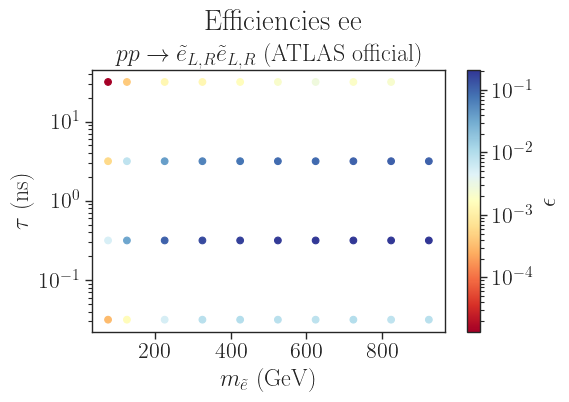

In [22]:
fig,ax =plt.subplots(figsize=(6,4),nrows=1,ncols=1)
df = atlas_ee
x = df['mLLP']
y = df['tau0_ns']
z = df['AccEff_Atlas_ee']
tit_append = ' (ATLAS official)'

im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$\epsilon$')

ax.set_title(title + tit_append)

plt.tight_layout()
plt.suptitle('Efficiencies ee', y=1.02)
plt.show()

In [23]:
dfRecastAtlas = dfRecast.merge(atlas_ee, on=['mLLP', 'tau0_ns'], how='inner')

In [26]:
dfRecastAtlas.columns

Index(['totalweight', 'Nevents', 'inputFile', 'llpPDG', 'Number of Events',
       'Integrated weight (pb)', 'Matched Integrated weight (pb)',
       'custom_fcts', 'mLLP', 'tau0_ns', 'Cross-Section (pb)', 'All',
       'All_err', 'Acceptance_ee', 'Acceptance_ee_err', 'AcceptanceCuts_ee',
       'AcceptanceCuts_ee_err', 'AccEff_ee', 'AccEff_ee_err', 'AccEffCuts_ee',
       'AccEffCuts_ee_err', 'Acceptance_mm', 'Acceptance_mm_err',
       'AcceptanceCuts_mm', 'AcceptanceCuts_mm_err', 'AccEff_mm',
       'AccEff_mm_err', 'AccEffCuts_mm', 'AccEffCuts_mm_err', 'Acceptance_em',
       'Acceptance_em_err', 'AcceptanceCuts_em', 'AcceptanceCuts_em_err',
       'AccEff_em', 'AccEff_em_err', 'AccEffCuts_em', 'AccEffCuts_em_err',
       'width_GeV', 'Efficiency', 'Acceptance', 'AccEff_Atlas_ee'],
      dtype='object')

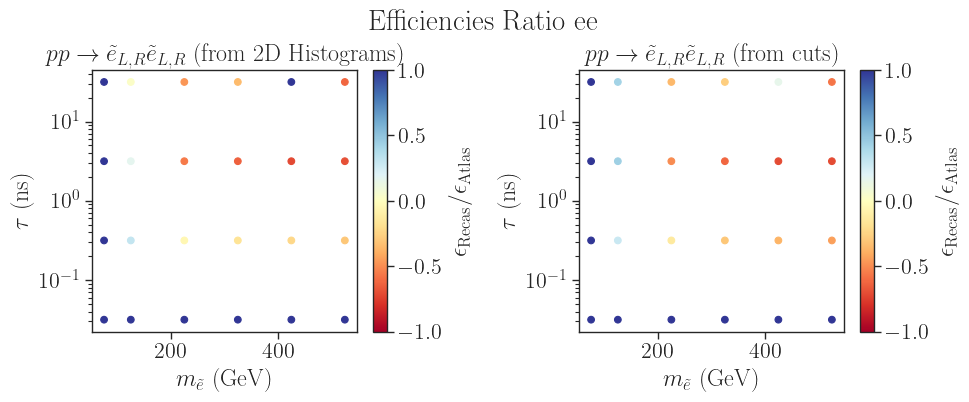

In [32]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

title = r'$p p \to \tilde{e}_{L,R} \tilde{e}_{L,R}$'
for iax,ax in enumerate(axList):
    df = dfRecastAtlas
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    if iax == 0:
        z = (df['AccEff_ee']-df['AccEff_Atlas_ee'])/df['AccEff_Atlas_ee']
        tit_append = ' (from 2D Histograms)'
    elif iax == 1:
        z = (df['AccEffCuts_ee']-df['AccEff_Atlas_ee'])/df['AccEff_Atlas_ee']
        tit_append = ' (from cuts)'
    else:
        raise ValueError("Invalid subplot index")

    # im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
    im = ax.scatter(x,y,c=z,cmap=cm,vmin=-1.0,vmax=1.0)
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon_{\rm Recas} / \epsilon_{\rm Atlas}$')

    ax.set_title(title + tit_append)

plt.tight_layout()
plt.suptitle('Efficiencies Ratio ee', y=1.02)
plt.show()